In [ ]:
import pandas as pd
import sklearn as sns


In [ ]:
df = pd.read_csv('SERT_qsar_InputFile_607entry.csv')

In [ ]:
df

,Molecule ChEMBL ID,Molecule Name,Molecular Weight,#RO5 Violations,AlogP,Smiles,Standard Value,Standard Units,pChEMBL Value,Value
0,CHEMBL257083,NaN,263.38,0.0,2.95,CNCC1CCCCC1(OC)c1cccc(OC)c1,2686.00,nM,5.57,2686.00
1,CHEMBL258336,NaN,247.38,0.0,3.28,CO[C@]1(c2ccccc2)CCCC[C@@H]1CN(C)C,2534.00,nM,5.60,2534.00
2,CHEMBL270570,NaN,305.46,0.0,4.16,CCCCO[C@]1(c2cccc(O)c2)CCCC[C@@H]1CN(C)C,2744.00,nM,5.56,2744.00
3,CHEMBL258140,NaN,319.49,0.0,4.46,CCCCO[C@]1(c2cccc(OC)c2)CCCC[C@@H]1CN(C)C,110.00,nM,6.96,110.00
4,CHEMBL256227,NaN,305.46,0.0,4.07,CCCO[C@]1(c2cccc(OC)c2)CCCC[C@@H]1CN(C)C,25.00,nM,7.60,25.00
...,...,...,...,...,...,...,...,...,...,...
602,CHEMBL549,CITALOPRAM,324.40,0.0,3.81,CN(C)CCCC1(c2ccc(F)cc2)OCc2cc(C#N)ccc21,13.41,nM,7.87,13.41
603,CHEMBL281350,SB-224289,520.63,2.0,5.58,Cc1nc(-c2ccc(-c3ccc(C(=O)N4CCc5cc6c(cc54)C4(CC...,4700.00,nM,5.33,4700.00
604,CHEMBL1683901,NaN,253.39,0.0,4.26,CNCC1(c2ccc3ccccc3c2)CCCCC1,34.00,nM,7.47,34.00
605,CHEMBL1683888,NaN,269.79,0.0,4.24,CN(C)CC1(c2ccc(Cl)c(F)c2)CCCCC1,145.00,nM,6.84,145.00


In [ ]:
df.isna().sum()

,0
Molecule ChEMBL ID,0
Molecule Name,524
Molecular Weight,0
#RO5 Violations,29
AlogP,29
Smiles,23
Standard Value,0
Standard Units,0
pChEMBL Value,0
Value,0


## For some enries 'Smiles' data are missing. So remove those entries

In [ ]:
# Ensure df is a DataFrame after filtering and reset index for robustness
df = df.dropna(subset=['Smiles']).reset_index(drop=True)
df = df[df['Smiles'].str.strip().astype(bool)].reset_index(drop=True)

In [ ]:
df

,Molecule ChEMBL ID,Molecule Name,Molecular Weight,#RO5 Violations,AlogP,Smiles,Standard Value,Standard Units,pChEMBL Value,Value
0,CHEMBL257083,NaN,263.38,0.0,2.95,CNCC1CCCCC1(OC)c1cccc(OC)c1,2686.00,nM,5.57,2686.00
1,CHEMBL258336,NaN,247.38,0.0,3.28,CO[C@]1(c2ccccc2)CCCC[C@@H]1CN(C)C,2534.00,nM,5.60,2534.00
2,CHEMBL270570,NaN,305.46,0.0,4.16,CCCCO[C@]1(c2cccc(O)c2)CCCC[C@@H]1CN(C)C,2744.00,nM,5.56,2744.00
3,CHEMBL258140,NaN,319.49,0.0,4.46,CCCCO[C@]1(c2cccc(OC)c2)CCCC[C@@H]1CN(C)C,110.00,nM,6.96,110.00
4,CHEMBL256227,NaN,305.46,0.0,4.07,CCCO[C@]1(c2cccc(OC)c2)CCCC[C@@H]1CN(C)C,25.00,nM,7.60,25.00
...,...,...,...,...,...,...,...,...,...,...
579,CHEMBL549,CITALOPRAM,324.40,0.0,3.81,CN(C)CCCC1(c2ccc(F)cc2)OCc2cc(C#N)ccc21,13.41,nM,7.87,13.41
580,CHEMBL281350,SB-224289,520.63,2.0,5.58,Cc1nc(-c2ccc(-c3ccc(C(=O)N4CCc5cc6c(cc54)C4(CC...,4700.00,nM,5.33,4700.00
581,CHEMBL1683901,NaN,253.39,0.0,4.26,CNCC1(c2ccc3ccccc3c2)CCCCC1,34.00,nM,7.47,34.00
582,CHEMBL1683888,NaN,269.79,0.0,4.24,CN(C)CC1(c2ccc(Cl)c(F)c2)CCCCC1,145.00,nM,6.84,145.00


In [ ]:
!pip install "numpy>=1.26"

In [ ]:
import numpy as np


In [ ]:
import matplotlib.pyplot as plt

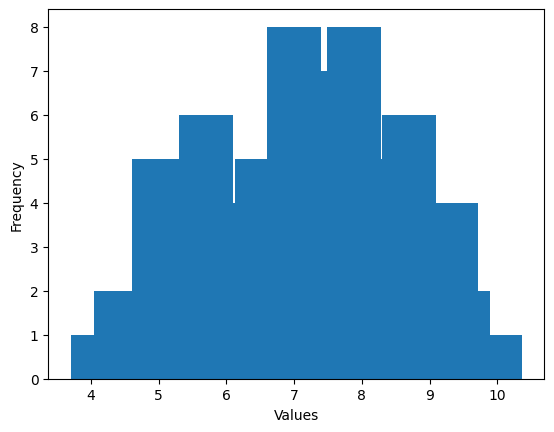

In [ ]:
target_column = 'pChEMBL Value'

frequency_dist = df[target_column].value_counts().to_dict()

values = list(frequency_dist.keys())
frequencies = list(frequency_dist.values())

plt.bar(values, frequencies)

plt.xlabel('Values')
plt.ylabel('Frequency')

plt.show()

In [ ]:
# IQR method to detect outliers in IC50Value
Q1 = df['pChEMBL Value'].quantile(0.25)
Q3 = df['pChEMBL Value'].quantile(0.75)
IQR = Q3 - Q1


# Define outlier boundaries
lower_bound = Q1 - 1.8 * IQR
upper_bound = Q3 + 1.8 * IQR

# Get outliers
outliers = df[(df['pChEMBL Value'] < lower_bound) | (df['pChEMBL Value'] > upper_bound)]

print("Outlier rows based on IC50Value:")
print(outliers)

Outlier rows based on IC50Value:
Empty DataFrame
Columns: [Molecule ChEMBL ID, Molecule Name, Molecular Weight, #RO5 Violations, AlogP, Smiles, Standard Value, Standard Units, pChEMBL Value, Value]
Index: []


In [ ]:
outliers.shape

(0, 10)

# NO OUTLIERS

In [ ]:
data_study = df.copy()

In [ ]:
data_study['Smiles']

,Smiles
0,CNCC1CCCCC1(OC)c1cccc(OC)c1
1,CO[C@]1(c2ccccc2)CCCC[C@@H]1CN(C)C
2,CCCCO[C@]1(c2cccc(O)c2)CCCC[C@@H]1CN(C)C
3,CCCCO[C@]1(c2cccc(OC)c2)CCCC[C@@H]1CN(C)C
4,CCCO[C@]1(c2cccc(OC)c2)CCCC[C@@H]1CN(C)C
...,...
579,CN(C)CCCC1(c2ccc(F)cc2)OCc2cc(C#N)ccc21
580,Cc1nc(-c2ccc(-c3ccc(C(=O)N4CCc5cc6c(cc54)C4(CC...
581,CNCC1(c2ccc3ccccc3c2)CCCCC1
582,CN(C)CC1(c2ccc(Cl)c(F)c2)CCCCC1


In [ ]:
data_study.isna().sum()

,0
Molecule ChEMBL ID,0
Molecule Name,524
Molecular Weight,0
#RO5 Violations,6
AlogP,6
Smiles,0
Standard Value,0
Standard Units,0
pChEMBL Value,0
Value,0


In [ ]:
# Below is required only when the IC50value has 0 value.

In [ ]:
#log, min-max, z-score
#logarithmic normalization
# Replace 0 values in 'Value' with a small positive number (e.g., 1e-9) before taking log10
df['IC50Value_safe'] = df['Value'].apply(lambda x: max(x, 1e-9))
df['Activity'] = np.log10(df['IC50Value_safe'])

In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 54.0 MB/s eta 0:00:00


In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors, rdMolDescriptors

In [ ]:
data_study.shape

(584, 10)

In [ ]:
molecules = [Chem.MolFromSmiles(smiles) for smiles in data_study['Smiles']]

In [ ]:
molecules

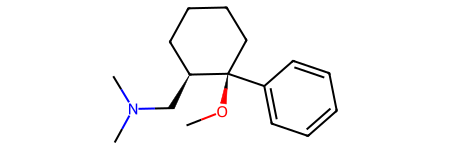

In [ ]:
#Visualize the molecule (each one)
molecules[1]

In [ ]:
len(molecules)

584

## 2D Desriptor Calculation

In [ ]:
MolWt_Desc = []  # creating a list to store the below calculated mw

for mol in molecules:
  mw = Descriptors.MolWt(mol)
  MolWt_Desc.append(mw)

In [ ]:
MolWt_Desc

In [ ]:
# Getting 2D Desc list

desc_list = [a[0] for a in Descriptors._descList]  # geting the predefined 'descList' from the Decsriptor function

In [ ]:
desc_list  # list all the descritpors

['MaxAbsEStateIndex',
 'MaxEStateIndex',
 'MinAbsEStateIndex',
 'MinEStateIndex',
 'qed',
 'SPS',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'NumValenceElectrons',
 'NumRadicalElectrons',
 'MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'FpDensityMorgan1',
 'FpDensityMorgan2',
 'FpDensityMorgan3',
 'BCUT2D_MWHI',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'BCUT2D_MRHI',
 'BCUT2D_MRLOW',
 'AvgIpc',
 'BalabanJ',
 'BertzCT',
 'Chi0',
 'Chi0n',
 'Chi0v',
 'Chi1',
 'Chi1n',
 'Chi1v',
 'Chi2n',
 'Chi2v',
 'Chi3n',
 'Chi3v',
 'Chi4n',
 'Chi4v',
 'HallKierAlpha',
 'Ipc',
 'Kappa1',
 'Kappa2',
 'Kappa3',
 'LabuteASA',
 'PEOE_VSA1',
 'PEOE_VSA10',
 'PEOE_VSA11',
 'PEOE_VSA12',
 'PEOE_VSA13',
 'PEOE_VSA14',
 'PEOE_VSA2',
 'PEOE_VSA3',
 'PEOE_VSA4',
 'PEOE_VSA5',
 'PEOE_VSA6',
 'PEOE_VSA7',
 'PEOE_VSA8',
 'PEOE_VSA9',
 'SMR_VSA1',
 'SMR_VSA10',
 'SMR_VSA2',
 'SMR_VSA3',
 'SMR_VSA4',
 'SMR_VSA5',
 'SMR_VSA6',


In [ ]:
len(desc_list)

217

In [ ]:
# 1. Divide the list into 2
# select first half for calculating descriptors
# second half is used to select the best one

from rdkit.ML.Descriptors import MoleculeDescriptors  # for Desc calculatiom
from sklearn.feature_selection import VarianceThreshold  # feature selection or descr selection by either removinf const feat or null feature so that the variance is non-zero


In [ ]:
# Desc Calculation

calculator = MoleculeDescriptors.MolecularDescriptorCalculator([a[0] for a in Descriptors._descList])
desc_name = calculator.GetDescriptorNames()

X = pd.DataFrame([calculator.CalcDescriptors(mol) for mol in molecules], columns=desc_name)
X

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,12.129003,12.129003,0.041062,-0.253711,0.778465,32.150000,315.196,299.068,314.047650,108,...,0,0,0,0,0,0,0,0,0,0
1,13.669258,13.669258,0.000000,-0.191455,0.170894,12.869565,704.534,666.230,702.192269,244,...,0,0,0,0,0,0,0,0,0,0
2,13.039448,13.039448,0.000000,-0.107995,0.265466,13.075000,633.492,592.164,631.201436,222,...,0,0,0,0,0,0,0,0,0,0
3,13.425010,13.425010,0.000000,-0.279429,0.340376,13.552632,564.577,524.257,563.259394,208,...,0,0,0,0,0,0,0,0,0,0
4,13.599894,13.599894,0.000000,-0.303300,0.239098,13.317073,598.594,560.290,597.243744,218,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2467,13.071344,13.071344,0.112685,-1.031947,0.625076,12.521739,341.501,322.349,341.090806,118,...,0,0,0,0,0,1,0,0,0,0
2468,11.351345,11.351345,0.199176,-0.543541,0.421693,14.696970,441.535,414.319,441.216475,168,...,0,0,0,0,0,0,0,0,1,0
2469,3.420510,3.420510,1.071985,1.071985,0.925960,15.238095,298.455,276.279,298.150370,110,...,0,0,0,0,0,0,0,0,0,0
2470,12.553434,12.553434,0.030668,-0.497330,0.865213,13.375000,325.368,306.216,325.142641,124,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# We have many 0 values for many descriptors. So we need to remove So we need to filter the X based on the threshold using the VarianceThreshold function
# and select using the selector.fit_transfor function

# define variable selector
# define threshold as 0 so that we omit variance 0 , ie the constant value descriptors will be omitted and use the rest in the  filtered

selector = VarianceThreshold(threshold=0)  # only those

# create another dataframe to get the filtered data
X_filtered = selector.fit_transform(X)
X_filtered = pd.DataFrame(X_filtered, columns= X.columns[selector.get_support()])

In [ ]:
X_filtered

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,12.129003,12.129003,0.041062,-0.253711,0.778465,32.150000,315.196,299.068,314.047650,108.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,13.669258,13.669258,0.000000,-0.191455,0.170894,12.869565,704.534,666.230,702.192269,244.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,13.039448,13.039448,0.000000,-0.107995,0.265466,13.075000,633.492,592.164,631.201436,222.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,13.425010,13.425010,0.000000,-0.279429,0.340376,13.552632,564.577,524.257,563.259394,208.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,13.599894,13.599894,0.000000,-0.303300,0.239098,13.317073,598.594,560.290,597.243744,218.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2467,13.071344,13.071344,0.112685,-1.031947,0.625076,12.521739,341.501,322.349,341.090806,118.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2468,11.351345,11.351345,0.199176,-0.543541,0.421693,14.696970,441.535,414.319,441.216475,168.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2469,3.420510,3.420510,1.071985,1.071985,0.925960,15.238095,298.455,276.279,298.150370,110.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2470,12.553434,12.553434,0.030668,-0.497330,0.865213,13.375000,325.368,306.216,325.142641,124.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3D Descriptors like Morgan FingerPrint and MACCKeys

In [ ]:
# Morgan Fingerprint

from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

In [ ]:
print(dir(rdFingerprintGenerator))

['AdditionalOutput', 'AtomInvariantsGenerator', 'AtomPairFP', 'AtomPairFingerprintOptions', 'BondInvariantsGenerator', 'FPType', 'FingerprintGenerator32', 'FingerprintGenerator64', 'FingerprintOptions', 'GetAtomPairAtomInvGen', 'GetAtomPairGenerator', 'GetCountFPs', 'GetFPs', 'GetMorganAtomInvGen', 'GetMorganBondInvGen', 'GetMorganFeatureAtomInvGen', 'GetMorganGenerator', 'GetRDKitAtomInvGen', 'GetRDKitFPGenerator', 'GetSparseCountFPs', 'GetSparseFPs', 'GetTopologicalTorsionGenerator', 'MorganFP', 'MorganFingerprintOptions', 'RDKitFP', 'RDKitFingerprintOptions', 'TopologicalTorsionFP', 'TopologicalTorsionFingerprintOptions', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__']


In [ ]:
# Apply this

# Define morgan_gen - use the radius for the neighboring atoms , atomsize in bits = 1024

morgan_gen = GetMorganGenerator(radius=2, fpSize = 1024)  # ---> change depends on the size . If we have smaller mole reduce the radius and also the number of bits. how many bits will be defined to each atom
# Define variable for fingerprints
morgan_fps = [morgan_gen.GetFingerprint(mol) for mol in molecules]

In [ ]:
len(morgan_fps)

584

In [ ]:
morgan_fps[0]

In [ ]:
# MACCSKeys Fingerprint  ---> apprach is diffe from morgan, they have predfined substructre, if it is present

from rdkit.Chem import MACCSkeys

In [ ]:
macc_fps = [MACCSkeys.GenMACCSKeys(mol) for mol in molecules]  # calculating maccskeys for each molecule in molecules

NameError: name 'MACCSkeys' is not defined

In [ ]:
# To Use MACCKeys fingerprint form of descriptors as X in ML

import numpy as np
X = np.array(macc_fps, dtype = float)

## Try Using Morgan and MACCKeys to generated better models with good R2 score >60 and less MSE

In [ ]:
# Use morgan fingerprint form of descriptors

import numpy as np
X = np.array(morgan_fps, dtype = float)

## Normalization **Not Required** for 3D descriptors

In [ ]:
# Normalization

from sklearn.preprocessing import StandardScaler
# Initialize variable scaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
len(X)

584

In [ ]:
y = data_study['pChEMBL Value']

In [ ]:
len(y)

584

In [ ]:
df_Morgan_data_retrieval_for_ML = pd.DataFrame(X)

In [ ]:
df_Morgan_data_retrieval_for_ML["value"] = data_study['pChEMBL Value']

In [ ]:
df_Morgan_data_retrieval_for_ML.head(10)

,0,1,2,3,4,5,6,7,8,9,...,1015,1016,1017,1018,1019,1020,1021,1022,1023,value
0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,5.57
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,5.60
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,5.56


In [ ]:
df_Morgan_data_retrieval_for_ML.to_csv("SERT_QSAR_RDkit_Dec_ML_X_MorganFingerprint_pChEMBL Value.csv")

In [ ]:
data_study.head(25)

,Molecule ChEMBL ID,Molecular Weight,AlogP,Smiles,IC50Value,IC50Value_safe,Activity
0,CHEMBL316342,315.20,3.82,COC(=O)C1C2CCC(CC1c1ccc(Cl)c(Cl)c1)O2,64.50,64.50,1.809560
2,CHEMBL3215850,704.53,5.08,Cc1c(Cl)cccc1N1CCN(CCCNC(=O)c2nc(-c3ccccc3)n(-...,181.70,181.70,2.259355
3,CHEMBL3216740,633.49,5.05,CCCc1nc(C(=O)NCCCN2CCN(c3cccc(Cl)c3C)CC2)c(C)n...,10.20,10.20,1.008600
4,CHEMBL3215618,564.58,4.83,CCCc1nc(C(=O)NCCCN2CCN(c3cccc(C)c3C)CC2)c(C)n1...,6.60,6.60,0.819544
5,CHEMBL3216737,598.59,5.55,Cc1cccc(N2CCN(CCCNC(=O)c3nc(-c4ccccc4)n(-c4ccc...,153.20,153.20,2.185259
6,CHEMBL3216967,592.61,3.67,CCCc1nc(C(=O)NCC(O)CN2CCN(c3cccc(C)c3C)CC2)c(C...,6.00,6.00,0.778151
7,CHEMBL3216288,609.40,3.50,Cc1c(Cl)cccc1N1CCN(CC(O)CNC(=O)c2nc(C)n(-c3ccc...,36.00,36.00,1.556303
8,CHEMBL256557,328.41,1.87,C=CCN(CC=C)C(=O)[C@@]1(c2ccc3c(c2)OCCO3)C[C@H]1CN,32.00,32.00,1.505150
9,CHEMBL257335,320.36,1.62,C=C(F)CN(C)C(=O)[C@@]1(c2ccc3c(c2)OCCO3)C[C@H]1CN,100.00,100.00,2.000000
11,CHEMBL3216959,655.47,5.89,Cc1c(Cl)cccc1N1CCN(CCCNC(=O)c2nc(-c3ccccc3)n(-...,281.90,281.90,2.450095


## Only if there is a NaN or Inf in 'Value' Column

In [ ]:
# Since there are inf value for y we can make it finite

# Replace inf with maximum finite value or cap it
finite_y = y[np.isfinite(y)]
max_ic50 = finite_y.max()

y = np.nan_to_num(y, posinf=max_ic50)

print("NaNs in y:", np.isnan(y).any())
print("Infs in y:", np.isinf(y).any())
print("nans in y:", np.isinf(y).any())

NaNs in y: False
Infs in y: False
nans in y: False


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
Linear_model = LinearRegression()
Linear_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = Linear_model.predict(X_test)

In [ ]:
y_train

,pChEMBL Value
375,6.85
330,5.04
451,5.50
489,6.51
305,7.86
...,...
440,7.70
554,4.10
318,8.05
60,5.24


In [ ]:
y_pred

array([ 2.74986402,  0.90492945,  0.61241946,  0.79137256,  1.55170658,
       -0.43063206,  3.18727228,  1.38185186,  5.01194506,  3.4093145 ,
        2.32176487,  1.25815394, -0.79822821, -2.35687414,  1.1115453 ,
        2.83387788,  2.76273765,  1.66955507,  3.9470798 ,  1.36556011,
        1.48734791,  0.11372158,  1.36407127,  3.92644795,  1.66231371,
        0.11372158,  0.84302817,  1.23922914,  1.83625883,  1.39995149,
        0.31507134,  1.15967407,  1.01103584,  0.71449204,  0.77916774,
        1.02559098,  1.31979167,  0.95812184, -0.29365345,  1.10332224,
        1.50514998,  4.99242786,  2.51674939,  8.06479559,  1.39663983,
        1.99288209,  0.2539083 , -0.70316498,  2.3539457 ,  3.07957194,
       11.33731073,  1.24203339,  1.07453022, -4.31985233, -2.21838418,
        2.41775143,  1.84471434,  0.94983445,  5.69424914,  3.18686401,
        1.91901691, -2.44896064,  1.60842707,  1.06283084,  3.21747861,
       -0.17062439,  2.32876892,  1.00190817,  2.32876892,  1.50

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse}')
print(f'r_squared: {r2}')

MSE: 1.1068694201061755
r_squared: 0.389586517754409


In [ ]:
from sklearn.ensemble import RandomForestRegressor
RF_model = RandomForestRegressor(n_estimators=100, random_state=42)  # estimators is number of decision trees
RF_model.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_rf = RF_model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

print (f'MSE : {mse}')
print (f'r_squared : {r2}')

MSE : 0.5008447814343481
r_squared : 0.7237954165627358


In [ ]:
import matplotlib.pyplot as plt

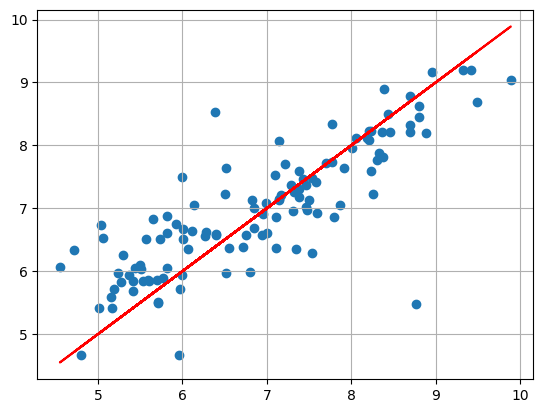

In [ ]:
plt.scatter(y_test, y_pred_rf)
plt.plot(y_test, y_test, color='red')

plt.grid(True)

plt.show()

## SAVE MODEL

In [ ]:
import pickle

In [ ]:
model = RF_model

filename = 'qsar_RF.pkl'
with open(filename, 'wb') as file:
    pickle.dump(model, file)

In [ ]:
#load model

In [ ]:
filename = 'qsar_RF.pkl'
with open(filename, 'rb') as file:
    loaded_RF = pickle.load(file)

## XGBoost

In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

# X = feature matrix (fingerprints/descriptors)
# y = pIC50 values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Convert to DMatrix (efficient format for XGBoost)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# XGBoost hyperparameters (good QSAR defaults)
params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8
}

# Train the model
model = xgb.train(params, dtrain, num_boost_round=300)

# Predict
y_pred = model.predict(dtest)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 0.6783896839067134
R²: 0.6764890274670656


## got good score with XGBoost RMSE ≈ 0.59.       pIC₅₀ (~≈4× IC₅₀ fold error) is typical for PubChem-style noisy data; the model should separate actives from inactives reasonably well and help pick candidates for testing.

# Save the model

In [ ]:
filename = 'sert_qsar_XGB.pkl'
with open(filename, 'wb') as file:
    pickle.dump(model, file)

In [ ]:
#Load model

In [ ]:
filename = 'sert_qsar_XGB.pkl'
with open(filename, 'rb') as file:
    loaded_XG = pickle.load(file)

## Prediction

In [ ]:
data_pred = pd.read_csv('Test-set-Glabridin-Glabrene-forActivityPrediction-uisngMLmodel.csv')
data_pred

,Molecule,Smiles
0,Glabridin,CC1(C)C=Cc2c(ccc3c2OC[C@@H](c2ccc(O)cc2O)C3)O1
1,Glabrene,CC1(C)C=Cc2c(O)ccc(C3=Cc4ccc(O)cc4OC3)c2O1
2,Paroxetine,Fc1ccc([C@@H]2CCNC[C@H]2COc2ccc3c(c2)OCO3)cc1


In [ ]:
molecules_pred = [Chem.MolFromSmiles(smiles) for smiles in data_pred['Smiles']]

In [ ]:
morgan_gen = GetMorganGenerator(radius=2, fpSize=1024)
morgan_fps = [morgan_gen.GetFingerprint(mol) for mol in molecules_pred]

In [ ]:
X_pred = np.array(morgan_fps, dtype=float)

In [ ]:
#scaler = StandardScaler()
#X = scaler.fit_transform(X)

# X_scaled = scaler.transform(X)  becasue, while training we fit the # ❌ Do NOT fit_transform again
# ✔️ Use scaler.transform(X) only

In [ ]:
X_scaled = scaler.transform(X)

In [ ]:
# convert to DMatrix  since we used DMatrix while training
dtest = xgb.DMatrix(X_pred)

In [ ]:
# predict
predicted = loaded_XG.predict(dtest)

In [ ]:
print (predicted)

[5.637214 6.069123 7.748294]


In [ ]:
def pic50_to_ic50_nM(predicted):
    # handle NaNs safely
    p = np.array(predicted, dtype=float)
    ic50_M = 10 ** (-p)            # IC50 in molar
    ic50_nM = ic50_M * 1e9         # IC50 in nM
    return ic50_nM

ic50_nM = pic50_to_ic50_nM(predicted)
# pretty print
for p_val, nM in zip(predicted[:10], ic50_nM[:10]):
    print(f"pIC50={p_val:.3f}  ->  IC50={nM:.1f} nM")

pIC50=5.828  ->  IC50=1485.6 nM
pIC50=5.881  ->  IC50=1316.5 nM
pIC50=7.740  ->  IC50=18.2 nM


In [ ]:
len(X)

3

In [ ]:
predicted_RF = loaded_RF.predict(X_pred)

In [ ]:
print (predicted_RF)

[7.01913    6.27264917 7.38112667]


In [ ]:
def pic50_to_ic50_nM(predicted_RF):
    # handle NaNs safely
    p = np.array(predicted_RF, dtype=float)
    ic50_M = 10 ** (-p)            # IC50 in molar
    ic50_nM = ic50_M * 1e9         # IC50 in nM
    return ic50_nM

ic50_nM = pic50_to_ic50_nM(predicted_RF)
# pretty print
for p_val, nM in zip(predicted_RF[:10], ic50_nM[:10]):
    print(f"pIC50={p_val:.3f}  ->  IC50={nM:.1f} nM")

pIC50=7.019  ->  IC50=95.7 nM
pIC50=6.273  ->  IC50=533.8 nM
pIC50=7.381  ->  IC50=41.6 nM


## Next Level

## GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
rf = RandomForestRegressor()

param_grid = {
    "n_estimators": [300, 600, 900],
    "max_depth": [None, 20, 40],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=7,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print("Best RF Parameters:", grid.best_params_)




Best RF Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 900}


In [ ]:
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, grid.predict(X_test))))

Test RMSE: 0.6985934691642182


In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

from sklearn.metrics import r2_score
print("Test R²:", r2_score(y_test, y_pred))

Test R²: 0.6569324921905831


In [ ]:
# SAVE THE MODEL

In [ ]:
filename = 'sert_qsar_RFRegressor_GridSeCV.pkl'
with open(filename, 'wb') as file:
    pickle.dump(best_model, file)

In [ ]:
filename = 'sert_qsar_RFRegressor_GridSeCV.pkl'
with open(filename, 'rb') as file:
    loaded_RFR = pickle.load(file)

In [ ]:
predicted_RFR = loaded_RFR.predict(X_pred)
print (predicted_RFR)

[6.44729708 6.29080414 7.51948007]


## Trying ENSEMBLE Model  A Combination of ExtraTrees and XGboost

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from xgboost import XGBRegressor
import numpy as np

In [ ]:
# =============================
# 9. Train ExtraTrees + XGBoost for Ensemble
# =============================

et = ExtraTreesRegressor(
    n_estimators=600,
    max_depth=None,
    random_state=42
)
et.fit(X_train, y_train)

xgb = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror"
)
xgb.fit(X_train, y_train)

# =============================
# 10. Predictions
# =============================
pred_rf  = best_rf.predict(X_test)
pred_et  = et.predict(X_test)
pred_xgb = xgb.predict(X_test)

# Ensemble prediction (average)
pred_ensemble = (pred_rf + pred_et + pred_xgb) / 3

# =============================
# 11. Accuracy Metrics
# =============================
rmse = np.sqrt(mean_squared_error(y_test, pred_ensemble))
r2 = r2_score(y_test, pred_ensemble)

print("\n⭐⭐ Ensemble Model Performance ⭐⭐")
print("RMSE :", rmse)
print("R² :", r2)

# =============================
# 12. Convert pIC50 → IC50 (nM)
# =============================
def pIC50_to_IC50(pic50):
    return 10**(9 - pic50)  # nM

df_results = pd.DataFrame({
    "Actual_pIC50": y_test,
    "Pred_pIC50": pred_ensemble,
})

df_results["Pred_IC50_nM"] = df_results["Pred_pIC50"].apply(pIC50_to_IC50)

df_results.head()


⭐⭐ Ensemble Model Performance ⭐⭐
RMSE : 0.7056812558482093
R² : 0.6499357920330351


,Actual_pIC50,Pred_pIC50,Pred_IC50_nM
383,6.80,7.502766,31.422017
422,6.42,7.472943,33.655559
90,8.12,7.789248,16.246200
472,6.19,6.818951,151.722268
522,7.00,6.976471,105.567247
